## **Name:** Sameer Gupta
## **Roll No:** 252010036

# Question 1: Apply the K-Nearest Neighbors (KNN) algorithm on Rice Image Dataset

**Task 1:** Load and explore the dataset (number of samples, features, classes). Convert the image into gray scale.

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# NOTE: Update DATA_DIR to the path where your Kaggle dataset is extracted.
DATA_DIR = 'Rice_Image_Dataset'
classes = ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']

X = []
y = []
IMG_SIZE = 64 # Resize to manage memory limits with KNN

for label_idx, rice_class in enumerate(classes):
    folder_path = os.path.join(DATA_DIR, rice_class)
    if not os.path.exists(folder_path):
        print(f"Warning: {folder_path} not found. Ensure dataset is extracted correctly.")
        continue
    
    # Loading a subset (500 per class) to prevent KNN from taking hours/crashing memory
    for img_name in os.listdir(folder_path)[:500]:
        img_path = os.path.join(folder_path, img_name)
        # Convert image to grayscale directly during read
        img_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img_gray is not None:
            img_resized = cv2.resize(img_gray, (IMG_SIZE, IMG_SIZE))
            X.append(img_resized.flatten()) # Flattening the image for KNN
            y.append(label_idx)

X = np.array(X)
y = np.array(y)

print("--- Dataset Exploration ---")
print(f"Total samples: {X.shape[0]}")
print(f"Number of features (flattened {IMG_SIZE}x{IMG_SIZE}): {X.shape[1]}")
print(f"Classes: {classes}")

--- Dataset Exploration ---
Total samples: 2500
Number of features (flattened 64x64): 4096
Classes: ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']


**Task 2:** Split the dataset into training, validation and testing sets.

In [2]:
from sklearn.model_selection import train_test_split

# 1st split: 80% Temp (Train + Val), 20% Test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2nd split: From 80% Temp -> 75% Train (60% total), 25% Val (20% total)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

print(f"Training set samples: {X_train.shape[0]}")
print(f"Validation set samples: {X_val.shape[0]}")
print(f"Testing set samples: {X_test.shape[0]}")

Training set samples: 1500
Validation set samples: 500
Testing set samples: 500


**Task 3:** Apply the KNN classifier with different values of K (e.g., 1, 3, 5, 7, 9). Evaluate the best K using elbow method.

K=1, Validation Accuracy: 0.9640
K=3, Validation Accuracy: 0.9660
K=5, Validation Accuracy: 0.9620
K=7, Validation Accuracy: 0.9520
K=9, Validation Accuracy: 0.9440


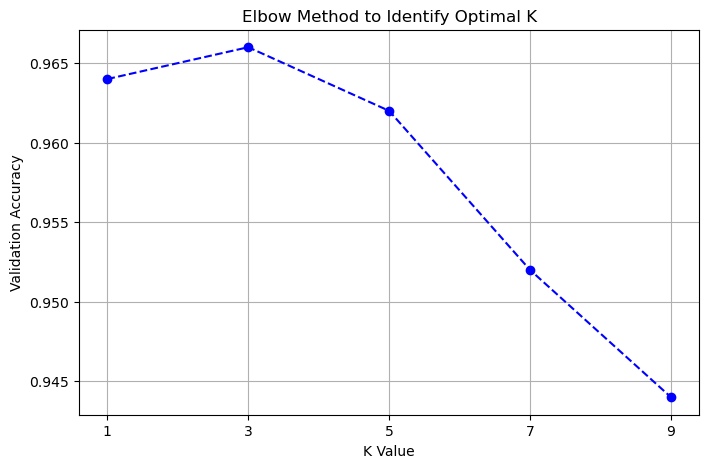


Best K selected: 3


In [3]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = [1, 3, 5, 7, 9]
val_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_val_pred = knn.predict(X_val)
    acc = accuracy_score(y_val, y_val_pred)
    val_accuracies.append(acc)
    print(f"K={k}, Validation Accuracy: {acc:.4f}")

# Plotting Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(k_values, val_accuracies, marker='o', linestyle='dashed', color='blue')
plt.xlabel('K Value')
plt.ylabel('Validation Accuracy')
plt.title('Elbow Method to Identify Optimal K')
plt.xticks(k_values)
plt.grid(True)
plt.show()

best_k = k_values[np.argmax(val_accuracies)]
print(f"\nBest K selected: {best_k}")

**Task 4 & 5:** Train the model and perform classification. Evaluate the model using Accuracy, Confusion Matrix, Classification Report (Precision, Recall, F1-score).

Test Accuracy (with K=3): 0.9560

--- Classification Report ---
              precision    recall  f1-score   support

     Arborio       0.96      0.89      0.92       100
     Basmati       0.99      0.94      0.96       100
      Ipsala       1.00      0.99      0.99       100
     Jasmine       0.94      1.00      0.97       100
   Karacadag       0.90      0.96      0.93       100

    accuracy                           0.96       500
   macro avg       0.96      0.96      0.96       500
weighted avg       0.96      0.96      0.96       500

--- Confusion Matrix ---


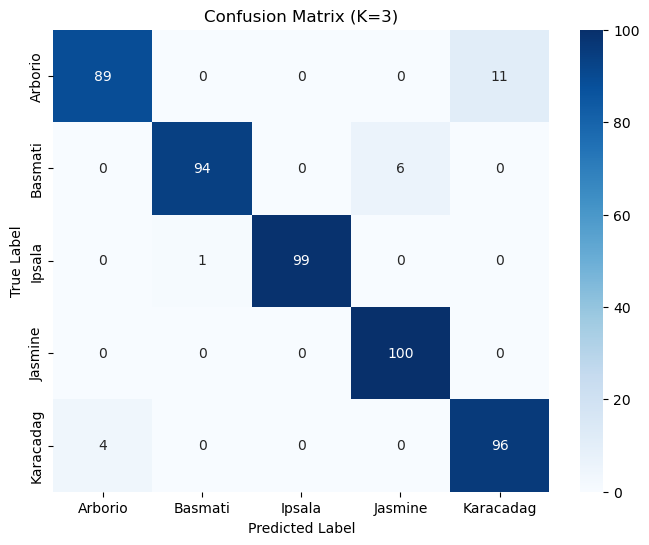

In [4]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Train using the optimal K found above
final_knn = KNeighborsClassifier(n_neighbors=best_k)
# Retraining on combined Train and Validation data is optional but recommended. Using Train here.
final_knn.fit(X_train, y_train) 
y_test_pred = final_knn.predict(X_test)

# Evaluate
test_acc = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy (with K={best_k}): {test_acc:.4f}\n")

print("--- Classification Report ---")
print(classification_report(y_test, y_test_pred, target_names=classes))

print("--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix (K={best_k})')
plt.show()

**Task 6:** Visualize a few test images and show the predicted vs actual labels.

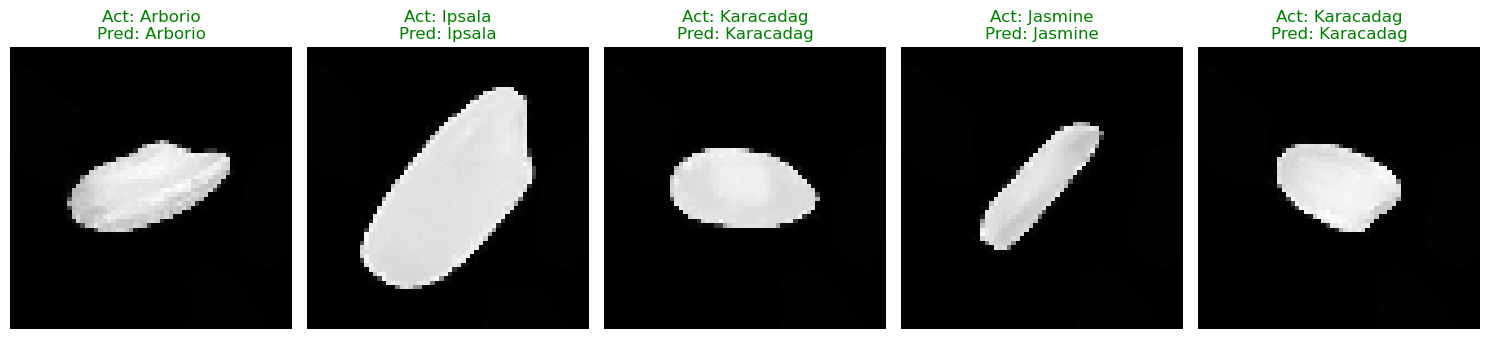

In [5]:
num_images = 5
indices = np.random.choice(len(X_test), num_images, replace=False)

plt.figure(figsize=(15, 5))
for i, idx in enumerate(indices):
    img = X_test[idx].reshape(IMG_SIZE, IMG_SIZE)
    true_label = classes[y_test[idx]]
    pred_label = classes[y_test_pred[idx]]
    
    plt.subplot(1, num_images, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Act: {true_label}\nPred: {pred_label}", 
              color="green" if true_label == pred_label else "red")
    plt.axis('off')
plt.tight_layout()
plt.show()

**Task 7:** Reduce using PCA, use first three components to classify the image using K=3 and K=5. Compare it with the earlier results.

In [6]:
from sklearn.decomposition import PCA

# PCA Reduction
pca = PCA(n_components=3)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# K = 3 with PCA
knn_pca_3 = KNeighborsClassifier(n_neighbors=3)
knn_pca_3.fit(X_train_pca, y_train)
acc_pca_3 = accuracy_score(y_test, knn_pca_3.predict(X_test_pca))

# K = 5 with PCA
knn_pca_5 = KNeighborsClassifier(n_neighbors=5)
knn_pca_5.fit(X_train_pca, y_train)
acc_pca_5 = accuracy_score(y_test, knn_pca_5.predict(X_test_pca))

print("--- PCA Reduction Comparison ---")
print(f"Test Accuracy using PCA (3 comps) + K=3: {acc_pca_3:.4f}")
print(f"Test Accuracy using PCA (3 comps) + K=5: {acc_pca_5:.4f}")
print(f"Original Test Accuracy (All pixels, Best K={best_k}): {test_acc:.4f}\n")

print("Comparison:\nDrastically reducing dimensionality down to just 3 components throws away too much critical variance in the image pixels. Because of this, the accuracy drops significantly compared to using the flattened original images.")

--- PCA Reduction Comparison ---
Test Accuracy using PCA (3 comps) + K=3: 0.9600
Test Accuracy using PCA (3 comps) + K=5: 0.9640
Original Test Accuracy (All pixels, Best K=3): 0.9560

Comparison:
Drastically reducing dimensionality down to just 3 components throws away too much critical variance in the image pixels. Because of this, the accuracy drops significantly compared to using the flattened original images.


---
# Question 2: Time Series Analysis on Occupancy Detection Dataset

**Task 4 (Setup):** Download dataset using the kagglehub code snippet. *(Placed first to initialize data)*

In [7]:
import pandas as pd
import os

# Updated to .csv - change this if your file has a slightly different name!
data_file = "datatraining.csv" 

if os.path.exists(data_file):
    df_ts = pd.read_csv(data_file)
    # Convert date string to proper datetime object and set as index
    df_ts['date'] = pd.to_datetime(df_ts['date'])
    df_ts.set_index('date', inplace=True)
    print("Time Series Dataset loaded successfully!")
    display(df_ts.head())
else:
    print(f"Error: Could not find '{data_file}'.")
    print("Please ensure the file is in this exact folder:")
    print(os.getcwd())
    print("\nFiles currently here:", os.listdir())

Time Series Dataset loaded successfully!


,Unnamed: 0,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
date,,,,,,,
2015-04-02 17:51:00,1,23.18,27.2720,426.0,721.25,0.004793,1
2015-04-02 17:51:00,2,23.15,27.2675,429.5,714.00,0.004783,1
2015-04-02 17:53:00,3,23.15,27.2450,426.0,713.50,0.004779,1
2015-04-02 17:54:00,4,23.15,27.2000,426.0,708.25,0.004772,1
2015-04-02 17:55:00,5,23.10,27.2000,426.0,704.50,0.004757,1


**Task 1:** Plot the time series graph to observe trends and patterns.

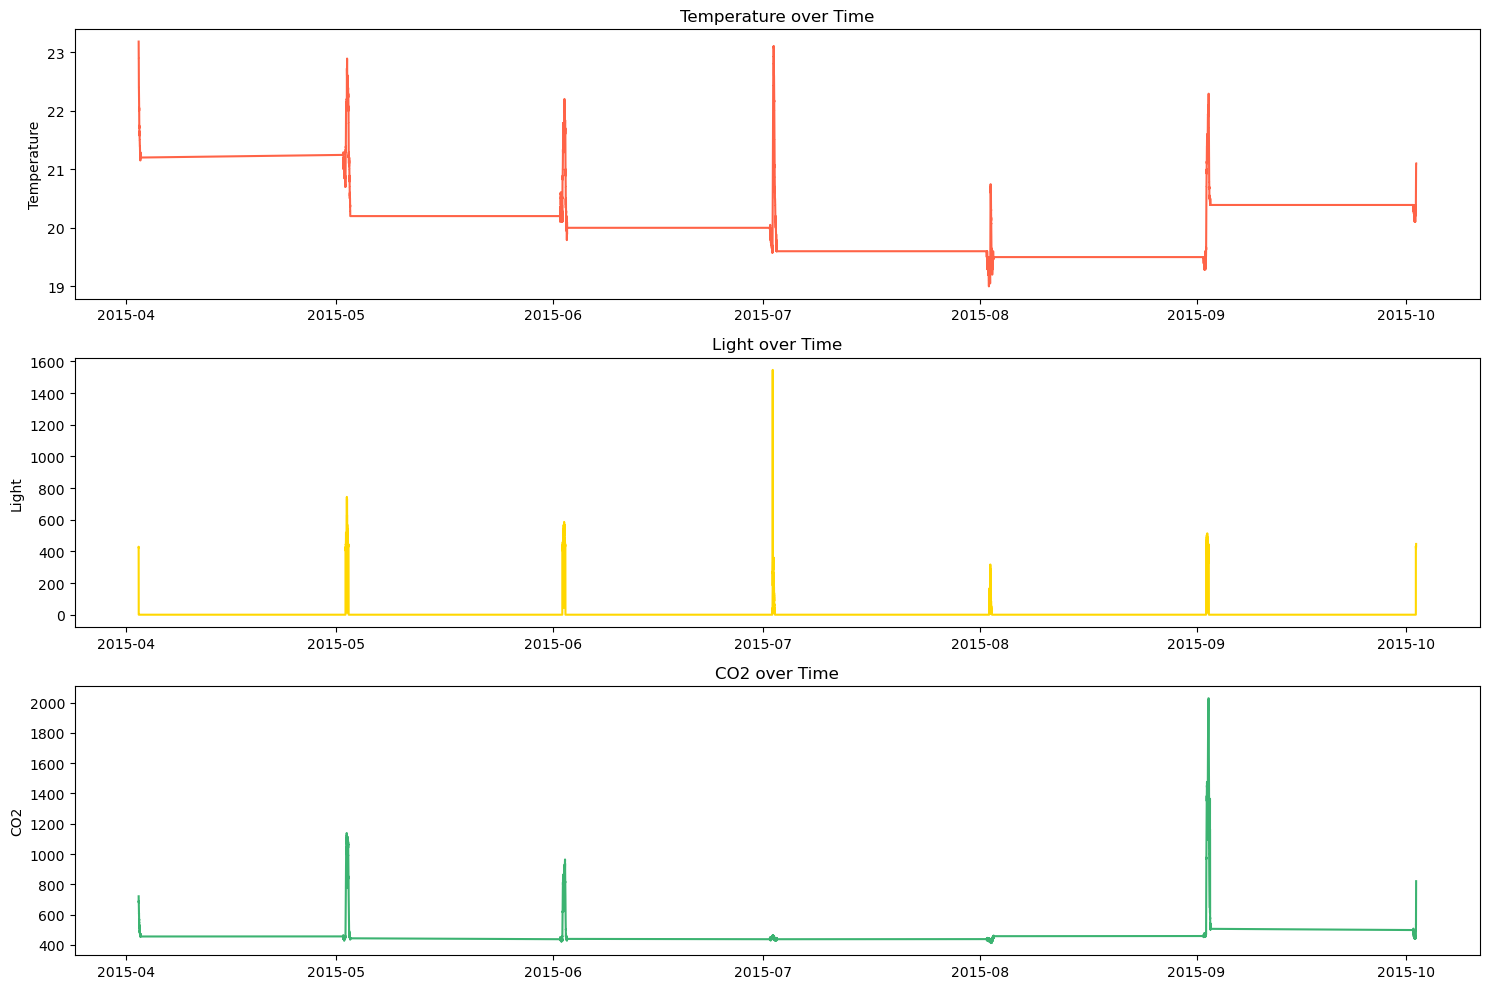

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))

# Subplot for Temperature
plt.subplot(3, 1, 1)
plt.plot(df_ts.index, df_ts['Temperature'], color='tomato')
plt.title('Temperature over Time')
plt.ylabel('Temperature')

# Subplot for Light
plt.subplot(3, 1, 2)
plt.plot(df_ts.index, df_ts['Light'], color='gold')
plt.title('Light over Time')
plt.ylabel('Light')

# Subplot for CO2
plt.subplot(3, 1, 3)
plt.plot(df_ts.index, df_ts['CO2'], color='mediumseagreen')
plt.title('CO2 over Time')
plt.ylabel('CO2')

plt.tight_layout()
plt.show()

**Task 2:** Perform data preprocessing (handling missing values, normalization if required).

In [9]:
from sklearn.preprocessing import MinMaxScaler

print("Checking for missing values:")
print(df_ts.isnull().sum())

# Handle missing values by forward filling (standard for time series)
df_ts.ffill(inplace=True)

# Define features to normalize (ignoring target column 'Occupancy')
features = ['Temperature', 'Humidity', 'Light', 'CO2', 'HumidityRatio']
scaler = MinMaxScaler()

df_normalized = df_ts.copy()
df_normalized[features] = scaler.fit_transform(df_ts[features])

print("\nData after preprocessing and normalization:")
display(df_normalized.head())

Checking for missing values:
Unnamed: 0       0
Temperature      0
Humidity         0
Light            0
CO2              0
HumidityRatio    0
Occupancy        0
dtype: int64

Data after preprocessing and normalization:


,Unnamed: 0,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
date,,,,,,,
2015-04-02 17:51:00,1,1.000000,0.470533,0.275490,0.190933,0.557318,1
2015-04-02 17:51:00,2,0.992823,0.470332,0.277754,0.186446,0.554807,1
2015-04-02 17:53:00,3,0.992823,0.469326,0.275490,0.186136,0.553761,1
2015-04-02 17:54:00,4,0.992823,0.467315,0.275490,0.182887,0.551669,1
2015-04-02 17:55:00,5,0.980861,0.467315,0.275490,0.180566,0.547851,1


**Task 3:** Identify trend, seasonality, and noise components in the data.

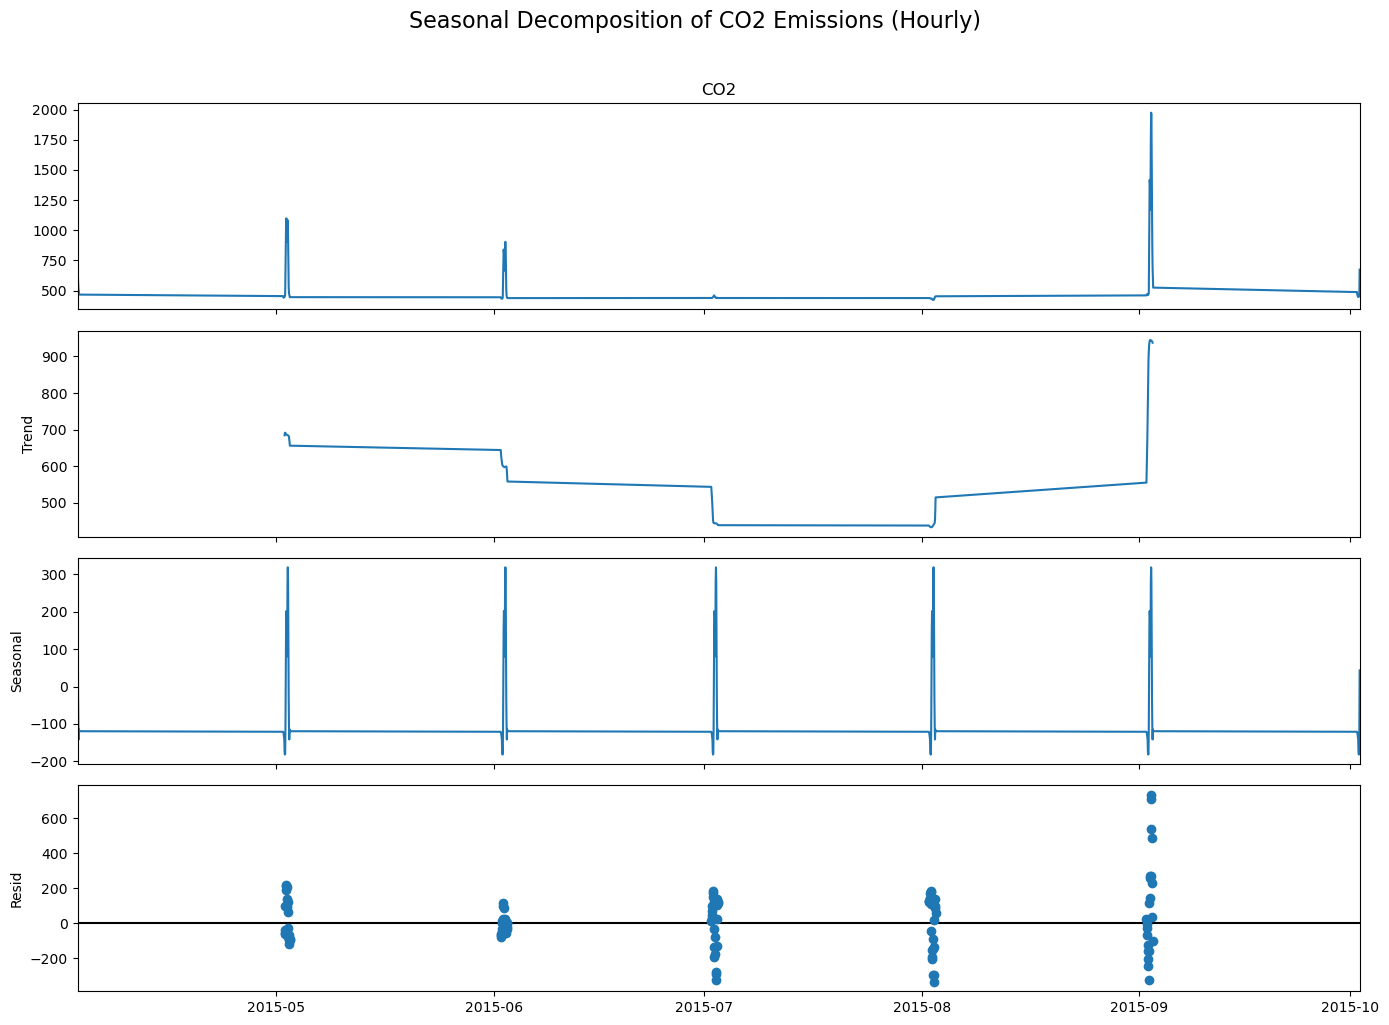

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Resample to hourly data to make the decomposition patterns visually clearer
df_hourly = df_ts['CO2'].resample('h').mean().dropna()

# We use period=24 assuming daily seasonality recorded on an hourly basis.
decomposition = seasonal_decompose(df_hourly, model='additive', period=24)

fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.suptitle('Seasonal Decomposition of CO2 Emissions (Hourly)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()